# QAT Bit-Width Sweep and Pareto Analysis

Execute a sweep over HGQ2 quantizer bit-width parameters and visualize the accuracy vs resource trade-off.

All sweep logic lives in ``bedposip.model.sweep`` — this notebook just orchestrates and visualizes.

## Imports

In [1]:
import os

from pathlib import Path

import matplotlib.pyplot as plt

from bedposip.model import run_sweep, plot_pareto, print_pareto_summary

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1785258102.535002  594403 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Run sweep

Sweep over random quantizer configurations. Results are returned as a DataFrame.

In [2]:
# Run sweep with expanded constraint search space
df = run_sweep(
    trials=20,
    notebook_path=Path('04_train_quantized_cnn.ipynb'),
)

Total combinations: 20
[1/20] run_0001: {'weight_bc': 10, 'weight_ic': 10, 'datalane_fc': 5, 'datalane_ic': 10, 'weight_i0': 4, 'weight_b0': 8, 'datalane_i0': 2, 'datalane_f0': 4}


I0000 00:00:1785258105.113095  595243 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785258107.366858  595243 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5194 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1785258114.992558  595332 service.cc:153] XLA service 0x7fbf2c0672d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785258114.992573  595332 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785258115.253285  595332 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=0.242, Acc=0.9082, EBOPs=4285102, LUTs=3407860, DSPs=15950
[2/20] run_0002: {'weight_bc': 8, 'weight_ic': 9, 'datalane_fc': 3, 'datalane_ic': 8, 'weight_i0': 4, 'weight_b0': 6, 'datalane_i0': 1, 'datalane_f0': 2}


I0000 00:00:1785258245.347176  606227 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785258247.592923  606227 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5280 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1785258255.245595  606298 service.cc:153] XLA service 0x7f755805d3c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785258255.245608  606298 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785258255.506187  606298 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=1.0986, Acc=0.3333, EBOPs=354060, LUTs=292308, DSPs=1123
[3/20] run_0003: {'weight_bc': 9, 'weight_ic': 8, 'datalane_fc': 6, 'datalane_ic': 8, 'weight_i0': 1, 'weight_b0': 6, 'datalane_i0': 3, 'datalane_f0': 3}


...

  [OK] Loss=0.2816, Acc=0.8920, EBOPs=2734170, LUTs=2189138, DSPs=9910
[19/20] run_0019: {'weight_bc': 7, 'weight_ic': 8, 'datalane_fc': 5, 'datalane_ic': 9, 'weight_i0': 2, 'weight_b0': 5, 'datalane_i0': 1, 'datalane_f0': 1}


I0000 00:00:1785260215.698198  728340 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785260217.721902  728340 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5181 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1785260225.221469  728409 service.cc:153] XLA service 0x7f1a1805e880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785260225.221482  728409 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785260225.466437  728409 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=0.3336, Acc=0.8702, EBOPs=2587743, LUTs=2073611, DSPs=9348
[20/20] run_0020: {'weight_bc': 8, 'weight_ic': 10, 'datalane_fc': 6, 'datalane_ic': 9, 'weight_i0': 4, 'weight_b0': 7, 'datalane_i0': 4, 'datalane_f0': 2}


I0000 00:00:1785260317.857226  733062 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785260319.947256  733062 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5181 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6
I0000 00:00:1785260327.374327  733132 service.cc:153] XLA service 0x7f183805fca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785260327.374346  733132 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785260327.619125  733132 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_C

  [OK] Loss=0.272, Acc=0.8960, EBOPs=3042966, LUTs=2432471, DSPs=11100

Done. 20 results collected.


### Accuracy vs EBOPs

EBOPs is a proxy for dynamic power consumption. Lower is better.

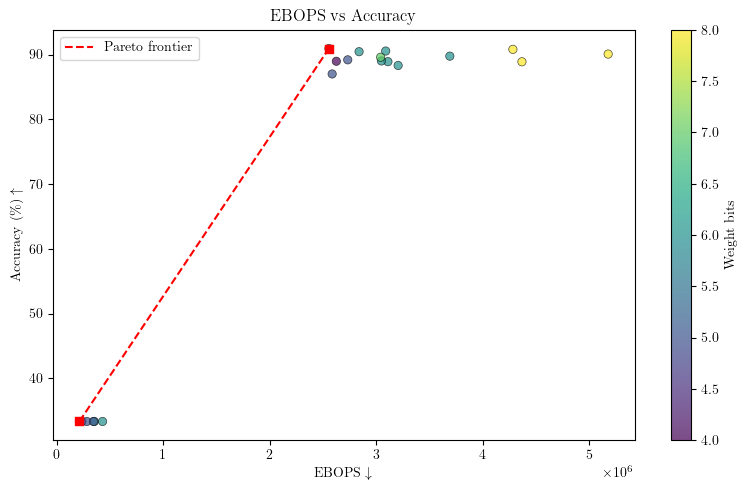

In [3]:
plot_pareto(
    df,
    resource='ebops',
    filename='pareto_ebops',
)

### Accuracy vs LUTs

LUTs measure FPGA fabric usage. Lower is better.

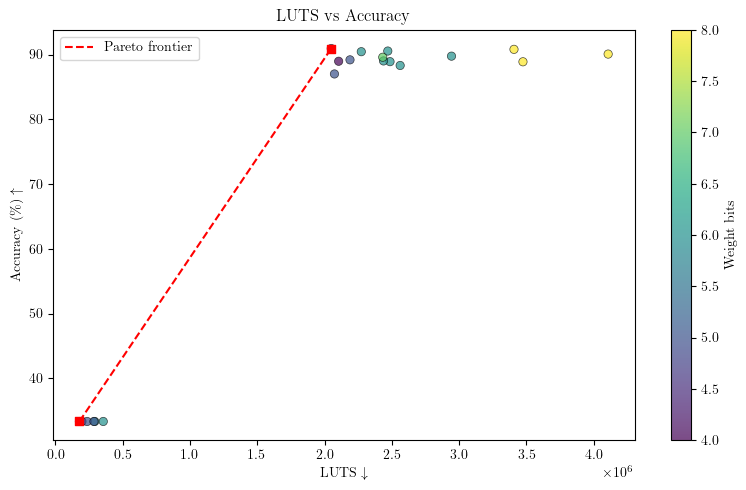

In [4]:
plot_pareto(
    df,
    resource='luts',
    filename='pareto_luts',
)

### Accuracy vs DSPs

DSPs are dedicated arithmetic blocks on the FPGA. Lower is better.

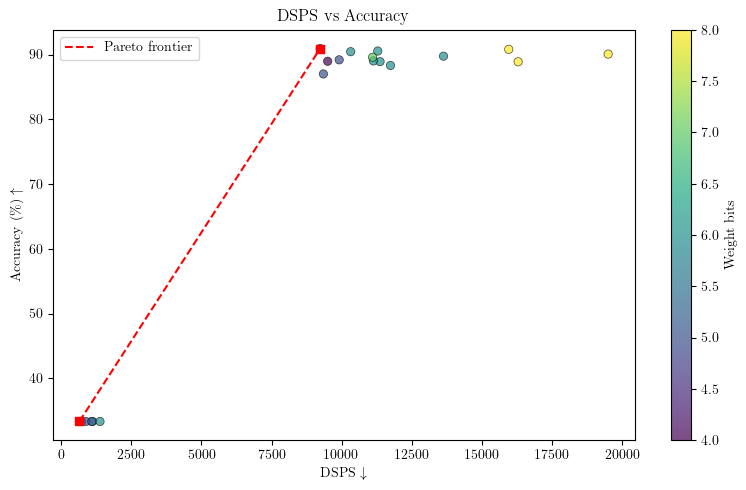

In [5]:
plot_pareto(
    df,
    resource='dsps',
    filename='pareto_dsps',
)

## Pareto summary

In [6]:
for resource in ['ebops', 'luts', 'dsps']:
    print_pareto_summary(df, resource=resource, threshold=0.90)
    print()

Runs with accuracy >= 90%: 5 out of 20

Pareto-optimal configurations (accuracy >= 90%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_bc w_ic w_i0 w_b0 d_fc d_ic d_i0 d_f0
-----------------------------------------------------------------------------------------------
run_0008      91.0%  2557286  2049569   9231     9    8    1    5    6    8    3    2

Runs with accuracy >= 90%: 5 out of 20

Pareto-optimal configurations (accuracy >= 90%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_bc w_ic w_i0 w_b0 d_fc d_ic d_i0 d_f0
-----------------------------------------------------------------------------------------------
run_0008      91.0%  2557286  2049569   9231     9    8    1    5    6    8    3    2

Runs with accuracy >= 90%: 5 out of 20

Pareto-optimal configurations (accuracy >= 90%):

Run ID          Acc    EBOPs     LUTs   DSPs  w_bc w_ic w_i0 w_b0 d_fc d_ic d_i0 d_f0
-----------------------------------------------------------------------------------------------
run_0008  